In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Phần 1 — Thống kê mô tả & đặc trưng** 

1.1 Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng
cột.

In [32]:
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


- Số dòng: 150
- Số cột: 51. 
- Cột 1(sepal_length): float64
- Cột 2(sepal_width): float64
- Cột 3(petal_length): float64
- Cột 4(petal_width): float64
- Cột 5(species): object

1.2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và
IQR.

In [33]:
columns = ['sepal_length','sepal_width','petal_length','petal_width']
for col in columns:
    mean_col = df[col].mean()
    median_col = df[col].median()
    mode_col = df[col].mode()[0]
    var_col = df[col].var()
    std_col = df[col].std()
    min_col = df[col].min()
    max_col = df[col].max()
    q1_col = df[col].quantile(0.25)
    q3_col = df[col].quantile(0.75)
    iqr_col = q3_col - q1_col
    
    print(f"Cột: {col}")
    print("Mean: ",mean_col)
    print("Median: ", median_col)
    print("Mode: ",mode_col)
    print("Var: ", var_col)
    print("Std: ", std_col)
    print("Min: ", min_col)
    print("Max: ", max_col)
    print("Q1: ", q1_col)
    print("Q3: ", q3_col)
    print("IQR: ", iqr_col)
    print("\n")

Cột: sepal_length
Mean:  5.843333333333334
Median:  5.8
Mode:  5.0
Var:  0.6856935123042505
Std:  0.8280661279778629
Min:  4.3
Max:  7.9
Q1:  5.1
Q3:  6.4
IQR:  1.3000000000000007


Cột: sepal_width
Mean:  3.0573333333333337
Median:  3.0
Mode:  3.0
Var:  0.1899794183445188
Std:  0.435866284936698
Min:  2.0
Max:  4.4
Q1:  2.8
Q3:  3.3
IQR:  0.5


Cột: petal_length
Mean:  3.7580000000000005
Median:  4.35
Mode:  1.4
Var:  3.1162778523489942
Std:  1.7652982332594667
Min:  1.0
Max:  6.9
Q1:  1.6
Q3:  5.1
IQR:  3.4999999999999996


Cột: petal_width
Mean:  1.1993333333333336
Median:  1.3
Mode:  0.2
Var:  0.5810062639821029
Std:  0.7622376689603465
Min:  0.1
Max:  2.5
Q1:  0.3
Q3:  1.8
IQR:  1.5




1.3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến.
Nhận xét nhóm nào khác biệt rõ nhất.

In [34]:
df.groupby('species').agg(['mean','std'])

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Dựa vào chiều dài cánh hoa(petal_length) và chiều rộng cánh hoa(petal_width), loài hoa setosa khác biệt nhất, cụ thể nhỏ hơn 2 loài hoa còn lại

**Phần 2 — Phân phối xác suất**

2.1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

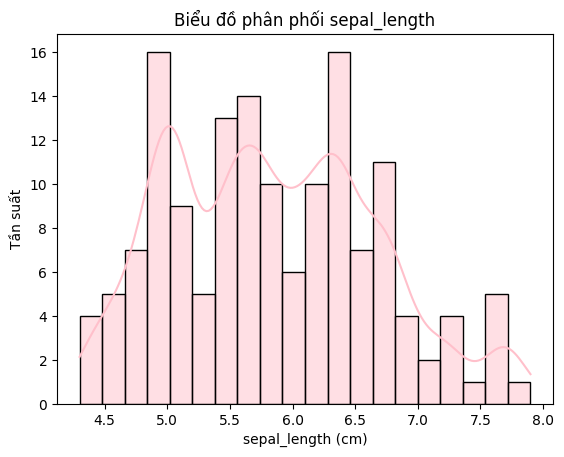

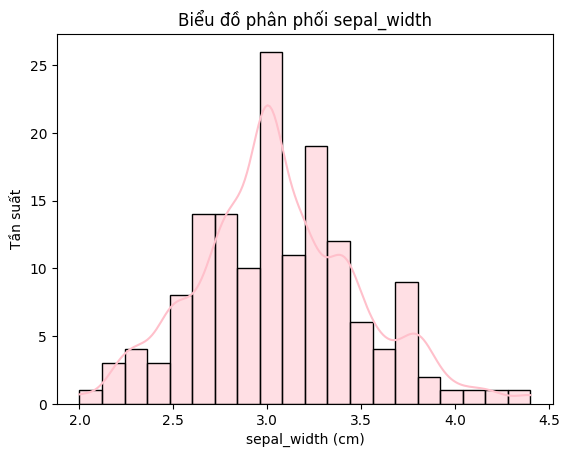

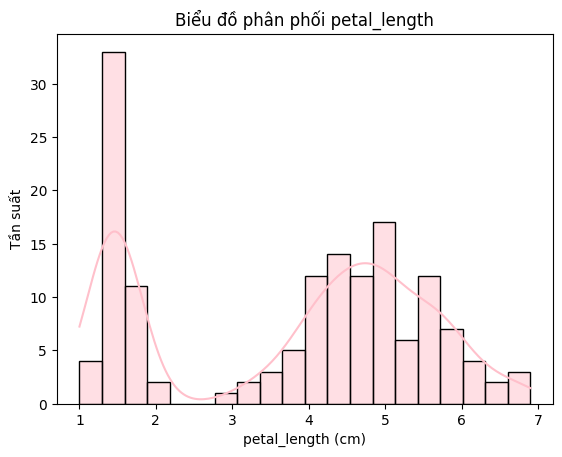

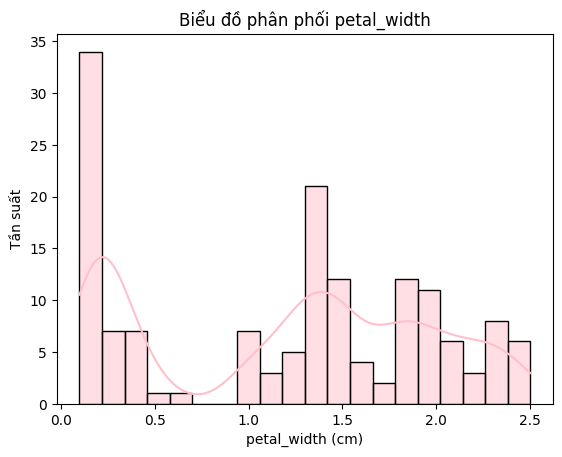

In [35]:
for col in columns:
    sns.histplot(df[col], bins=20, kde=True, color="pink", kde_kws={'bw_adjust': 0.5})
    plt.title(f"Biểu đồ phân phối {col}")
    plt.xlabel(f"{col} (cm)")
    plt.ylabel("Tần suất")
    plt.locator_params(axis='y', integer=True)
    plt.show()
    print("\n")

- Đài hoa(length): nhiều đỉnh
- Đài hoa(width): gần phân phối chuẩn
- Cánh hoa(length): lệch trái
- Cánh hoa(width): lệch trái

2.2 Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài

In [36]:
df_species = df.groupby('species')
print(df_species.head())

     sepal_length  sepal_width  petal_length  petal_width     species
0             5.1          3.5           1.4          0.2      setosa
1             4.9          3.0           1.4          0.2      setosa
2             4.7          3.2           1.3          0.2      setosa
3             4.6          3.1           1.5          0.2      setosa
4             5.0          3.6           1.4          0.2      setosa
50            7.0          3.2           4.7          1.4  versicolor
51            6.4          3.2           4.5          1.5  versicolor
52            6.9          3.1           4.9          1.5  versicolor
53            5.5          2.3           4.0          1.3  versicolor
54            6.5          2.8           4.6          1.5  versicolor
100           6.3          3.3           6.0          2.5   virginica
101           5.8          2.7           5.1          1.9   virginica
102           7.1          3.0           5.9          2.1   virginica
103           6.3   

/tmp/ipykernel_58/3486965811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=species_col, data=df, palette='muted')
/tmp/ipykernel_58/3486965811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=species_col, data=df, palette='muted')
/tmp/ipykernel_58/3486965811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=species_col, data=df, palette='muted')
/tmp/ipykernel_58/3486965811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` varia

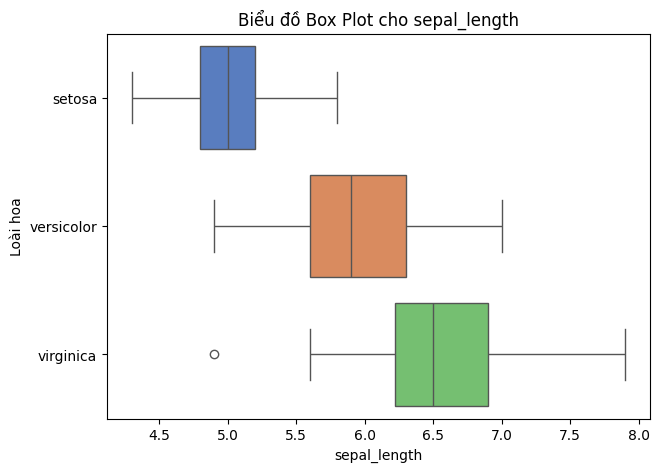

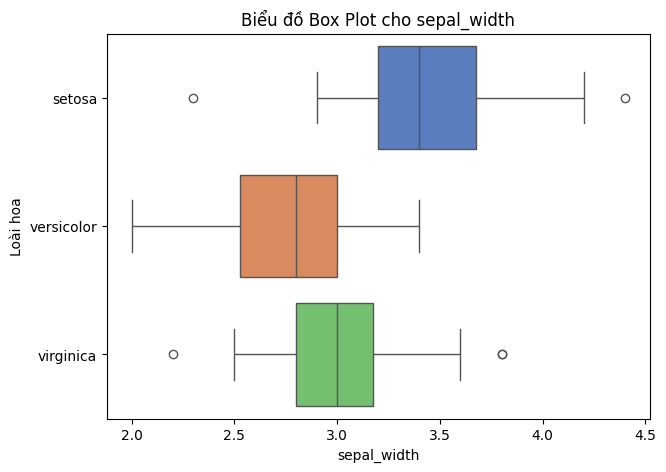

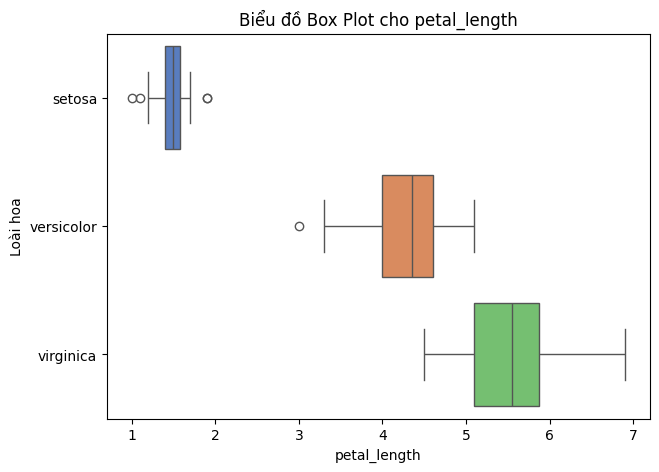

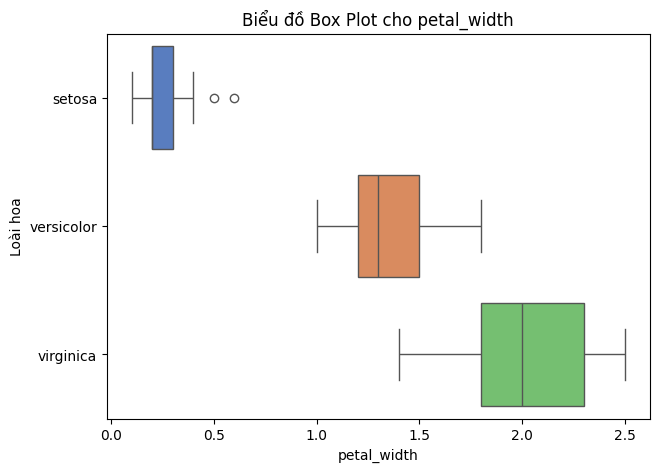

In [50]:
species_col = df.columns[-1]
for col in columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=col, y=species_col, data=df, palette='muted')
    plt.title(f'Biểu đồ Box Plot cho {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Loài hoa')

2.3  Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. Nhận xét mức độ khớp

3.0573333333333337 0.435866284936698
[3.27524743 3.16296052 3.15707482 ... 2.68631538 3.00394693 2.98793792]


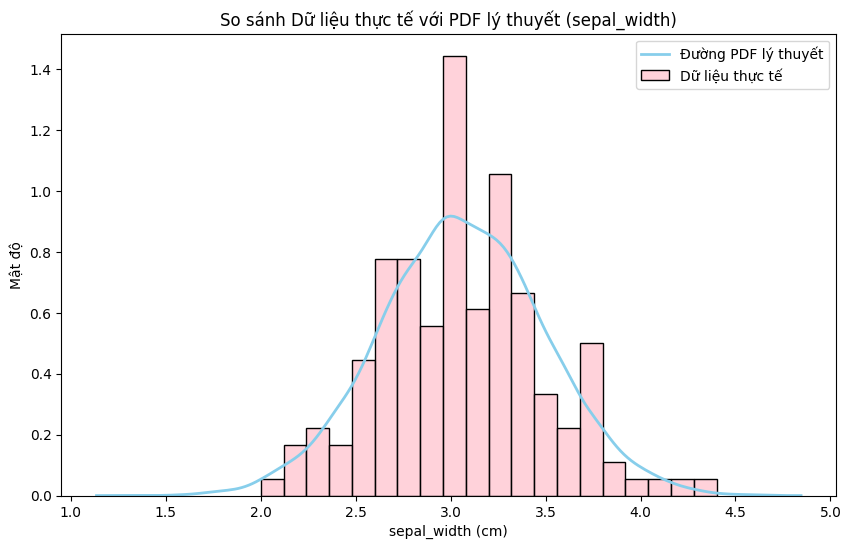

In [38]:
col_chosen = 'sepal_width'
mean_chosen = df[col_chosen].mean()
std_chosen = df[col_chosen].std()

sample = np.random.normal(loc=mean_chosen, scale=std_chosen, size=10000)
print(mean_chosen, std_chosen)
print(sample)

plt.figure(figsize=(10,6))
sns.histplot(df[col_chosen], bins=20, stat='density', color="pink", label='Dữ liệu thực tế', alpha=0.7)
sns.kdeplot(sample, color="skyblue", linewidth=2, label="Đường PDF lý thuyết")
plt.title(f"So sánh Dữ liệu thực tế với PDF lý thuyết ({col_chosen})")
plt.xlabel(f"{col_chosen} (cm)")
plt.ylabel("Mật độ")
plt.legend()
plt.show()



Dữ liệu trong cột sepal_width gần với phân phối chuẩn. Cụ thể dữ liệu tập trung ở vùng trung tâm và giảm dần về hai phía tạo thành hình chuông đối xứng tương đối

**Phần 3 — Phân tích đa biến & tương quan**

3.1 Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số.

- Ma trận hiệp phương sai

In [39]:
covariance_matrix = df[columns].cov()
print(covariance_matrix)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006


- Ma trận tương quan

In [40]:
correlation_matrix = df[columns].corr()
print(correlation_matrix)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


3.2 Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

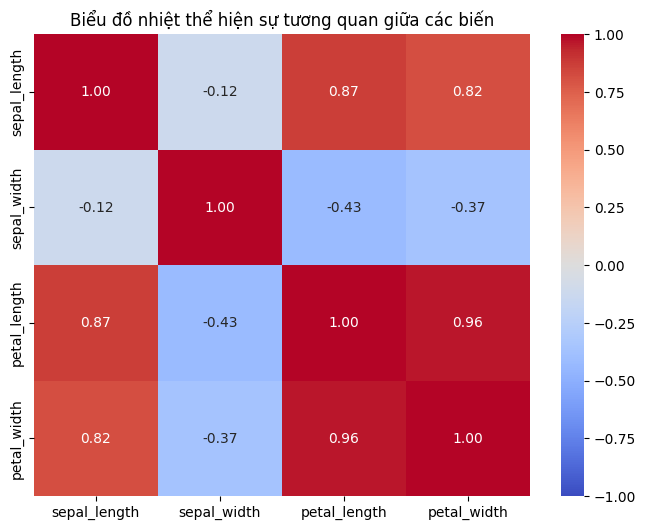

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Biểu đồ nhiệt thể hiện sự tương quan giữa các biến")
plt.show()

Dựa vào heatmap, ngoài các ô ở đường chéo chính (tương quan với chính nó), có các ô với độ tương quan cao (>0.8) ví dụ sepallength-petallength, sepallength-petalwidth, petallength-petalwidth,...
=> có dấu hiệu đa cộng tuyến

3.3 Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến

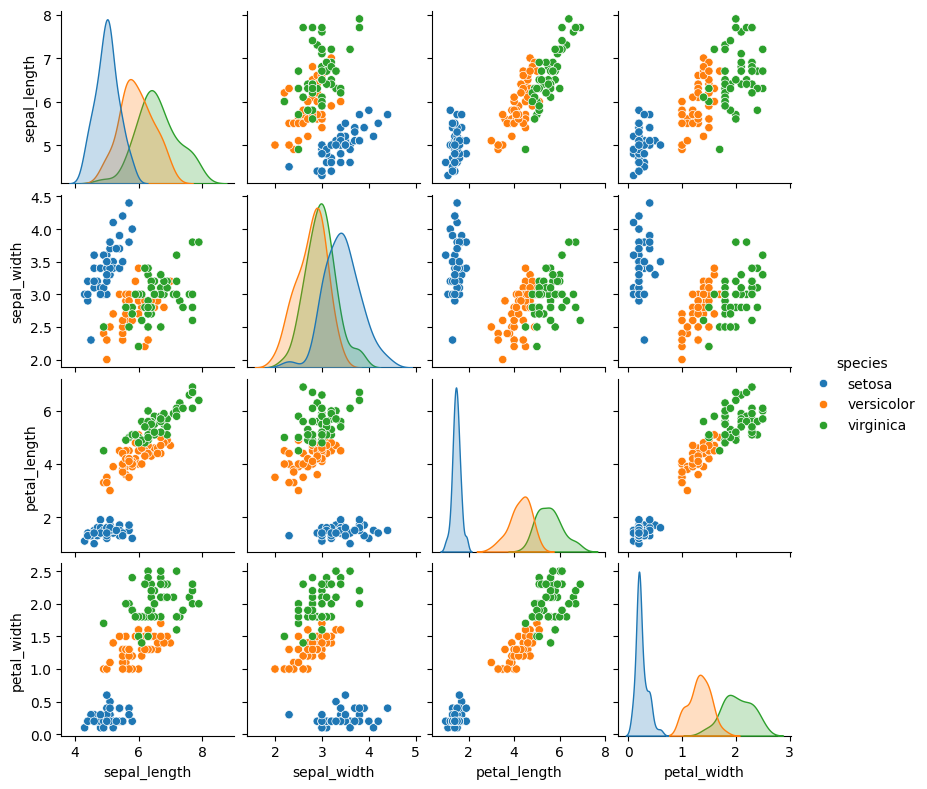

In [42]:
sns.pairplot(df, hue='species', height=2);

Nhận xét bổ sung:
- Khi các chấm tròn xếp thành 1 hàng đi lên từ trái sang phải: tương quan dương (X tăng -> Y tăng)
- Khi các chấm tròn xếp thành 1 hàng đi xuống từ trái sang phải: tương quan âm (X tăng-> Y giảm)
- Khi các chấm tròn rải rác: Không tương quan tuyến tính

Nhận xét quan hệ giữa các biến (theo từng loài hoa):
- Sepal_length - sepal_width: các chấm tròn xếp thành đường thẳng đi lên (theo từng loài hoa) -> Tỷ lệ thuận (đài hoa càng dài thì chúng càng rộng)
- Sepal_length - petal_length: versiscolor, virginica tỷ lệ thuận, riêng setosa có độ tương quan gần 0 vì các chấm tròn xếp thành 1 hàng ngang (tương đối)
- Sepal_length - petal_width: Không tương quan
- Sepal_width - petal_length: versiscolor, virginica tỷ lệ thuận, riêng setosa có độ tương quan gần 0 vì các chấm tròn xếp thành 1 hàng ngang (tương đối)
- Sepal_width - petal_width: versiscolor, virginica tỷ lệ thuận, riêng setosa có độ tương quan gần 0 vì các chấm tròn xếp thành 1 hàng ngang (tương đối)
- Petal_length - petal_width: các chấm tròn xếp thành đường thẳng đi lên (theo từng loài hoa) -> Tỷ lệ thuận (cánh hoa càng dài thì chúng càng rộng)

- Dựa vào pairplot, loài hoa setosa luôn nằm riêng lẻ với 2 loài hoa còn lại
- Có thể dựa vào đồ thị giữa petal_length - petal_width để phân biệt các loài hoa bởi vì chúng ít chồng lên nhau

**Phần 4 — Xác suất & Định lý Bayes**

Bài toán chẩn đoán. Một bệnh có tỉ lệ mắc trong dân số là P(B) = 0.01. Một xét
nghiệm có:
- Độ nhạy (true positive): P(+ | B) = 0.99.
- Dương tính giả (false positive): P(+ | ¬B) = 0.05.

4.1. Viết code tính xác suất hậu nghiệm P(B | +) bằng định lý Bayes và in kết quả

In [43]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1- P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos
print(round(P_B_given_pos, 4))

0.1667


4.2. Khảo sát: vẽ đồ thị P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

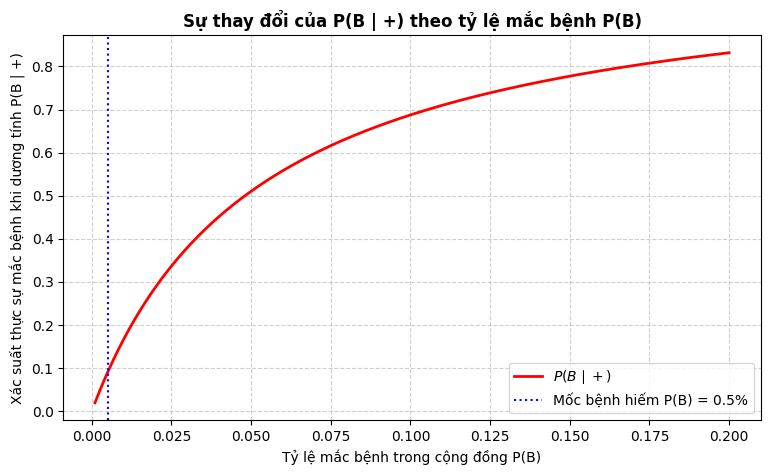

In [44]:
P_B_create = np.linspace(0.001, 0.2, 1000)
P_B_given_pos1 = (P_pos_givenB * P_B_create) / (P_pos_givenB * P_B_create + P_pos_givnNB * (1 - P_B_create))

plt.figure(figsize=(9,5))
plt.plot(P_B_create, P_B_given_pos1, color='red', linewidth=2, label=r'$P(B \mid +)$')
plt.title('Sự thay đổi của P(B | +) theo tỷ lệ mắc bệnh P(B)', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ lệ mắc bệnh trong cộng đồng P(B)', fontsize=10)
plt.ylabel('Xác suất thực sự mắc bệnh khi dương tính P(B | +)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=0.005, color='blue', linestyle=':', label='Mốc bệnh hiếm P(B) = 0.5%')
plt.legend()

plt.show()

- Nếu bệnh với tỉ lệ mắc là 20% (không hiếm), người bệnh đi xét nghiệm, 99% kết quả dự đoán chính xác, hơn 80% họ thật sự bị bệnh
- Nếu bệnh hiếm với tỉ lệ mắc bệnh là 0.5%, người bệnh đi xét nghiệm, 99% kết quả dự đoán chính xác nhưng chỉ có gần 10% họ thật sự bị bệnh
=> Sự phản trực giác ở đây là tuy khả năng dự đoán chính xác 99%, chỉ có 1% sai nhưng khả năng họ thật sự bị bệnh thấp hơn so với khi mắc bệnh phổ biến. Nghĩa là khả năng họ thật sự bị bệnh phụ thuộc vào mức độ phổ biến của bệnh đó trong cộng đồng

**(Tùy chọn, bonus) Xây dựng một bộ lọc spam đơn giản theo Naive Bayes trên vài
từ khóa cho sẵn; tính P(spam | email) cho 2–3 email ví dụ.**

In [45]:
words_spam = ['buy','free','sale','bonus', 'cash']
P_spam = 0.5
P_pos_given_spam = {'buy':0.6, 'free':0.9, 'sale':0.7, 'bonus':0.8, 'cash':0.4}
P_pos_given_nspam = {'buy':0.1, 'free':0.3, 'sale':0.1, 'bonus':0.4, 'cash':0.2}

In [46]:
def spam_recognize(email_text):
    words_email = email_text.lower().split()
    P_email_given_spam = 1.0
    P_email_given_nspam = 1.0
    for word in words_spam:
        if word in words_email:
            P_email_given_spam *= P_pos_given_spam[word]
            P_email_given_nspam *= P_pos_given_nspam[word]
        else:
            P_email_given_spam *= (1 - P_pos_given_spam[word])
            P_email_given_nspam *= (1 - P_pos_given_nspam[word])
    numerator = P_email_given_spam * P_spam
    denominator = (P_email_given_spam * P_spam) + (P_email_given_nspam * (1 - P_spam))
    result = numerator / denominator
    return result

In [47]:

email_1 = "URGENT: Your account has been credited with a $5,000 cash prize! Claim your 200% welcome bonus today. Click the link below to get your free reward before it expires in 24 hours!"
email_2 = "LAST CHANCE: Cyber Monday mega sale is now live! Buy any laptop today and get a smartphone completely free. Limited stock available, click here to shop the deals now!"
email_3 = "Hey! Did you buy the textbooks for our machine learning class next week yet? Let me know if you want to study together at the library this weekend."

print("Xác suất Spam của email spam 1: ", spam_recognize(email_1))
print("Xác suất Spam của email spam 2: ", spam_recognize(email_2))
print("Xác suất Spam của email thường 3: ", spam_recognize(email_3))

Xác suất Spam của email spam 1:  0.64
Xác suất Spam của email spam 2:  0.5999999999999999
Xác suất Spam của email thường 3:  0.06666666666666662
